# Curvas de Transferencia — EGOFET

Análisis de curvas $I_{DS}$ vs $V_{GS}$ a $V_{DS}$ constante.
De aquí extraemos: $V_{th}$, movilidad, $SS$, relación $I_{on}/I_{off}$.

In [10]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import SaveConfig, record_script, save_result
from src.readers import read_hdf5, list_measurements
from src.plotting import plot_transfer, plot_transfer_multi
from src.analysis import (
    extract_vth_linear,
    extract_vth_sqrt,
    extract_mobility,
    extract_ss,
    extract_on_off_ratio,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [11]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data/raw/2026-06-26_test1.hdf5')
OUT_DIR = os.path.join(PROJECT_ROOT, 'output')
os.makedirs(OUT_DIR, exist_ok=True)

measurements = read_hdf5(DATA_PATH)
display(list_measurements(measurements))

,name,mode,batch,device,n_points,columns
0,Batch1_Dispositivo1_Output1_00,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
1,Batch1_Dispositivo1_Output2_00,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
2,Batch1_Dispositivo1_Transfer1_00,transfer,Batch1,,162,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
3,Batch1_Dispositivo1_Transfer1_01,transfer,Batch1,,324,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
4,Batch1_Dispositivo1_Transfer2_00,transfer,Batch1,,324,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
5,Batch1_Dispositivo2_Output_00,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
6,Batch1_Dispositivo2_Output_01,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
7,Batch1_Dispositivo2_Output_02,transfer,Batch1,,324,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
8,Batch1_Dispositivo2_Output_03,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
9,Batch1_Dispositivo2_Transfer1_00,transfer,Batch1,,324,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"


In [12]:
transfer_ms = {n: m for n, m in measurements.items() if m.mode == 'transfer'}
display(list_measurements(transfer_ms))

,name,mode,batch,device,n_points,columns
0,Batch1_Dispositivo1_Transfer1_00,transfer,Batch1,,162,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
1,Batch1_Dispositivo1_Transfer1_01,transfer,Batch1,,324,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
2,Batch1_Dispositivo1_Transfer2_00,transfer,Batch1,,324,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
3,Batch1_Dispositivo2_Output_02,transfer,Batch1,,324,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
4,Batch1_Dispositivo2_Transfer1_00,transfer,Batch1,,324,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
5,Batch1_Dispositivo2_Transfer2_00,transfer,Batch1,,324,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
6,Batch1_Dispositivo2_Transfer3_00,transfer,Batch1,,324,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
7,Batch2_Dispositivo1_Output_00,transfer,Batch2,,484,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
8,Batch2_Dispositivo1_Transfer_00,transfer,Batch2,,484,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
9,Batch2_Dispositivo1_Transfer_01,transfer,Batch2,,484,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"


# Save Configuration

This object controls everything: where to write, which formats, what extras.

In [13]:
SAVE = SaveConfig(
    enabled=True,                                # master switch
    output_dir=OUT_DIR,    # base directory (project root)
    formats=['png'],                      # image formats
    save_data=True,                              # also save CSV
    save_code=True,                              # also save the script
    save_latex=False,                             # also save LaTeX snippet
    dpi=300,                                     # raster resolution
    overwrite=True,                              # overwrite existing files
)
print(SAVE)

SaveConfig(enabled=True, output_dir='/home/dibarra/Documents/egofets-project/output', basename='', formats=['png'], save_data=True, save_code=True, save_latex=False, dpi=300, overwrite=True)


## Batch 3 — Dispositivo 1

In [14]:
mt = measurements['Batch3_Dispositivo1_Transfer_01']
print(mt)
print('V_DS values:', sorted(mt.data['V_DS'].unique()))

Measurement('Batch3_Dispositivo1_Transfer_01', mode='transfer', 484 points)
V_DS values: [np.float64(-0.8), np.float64(-0.4)]


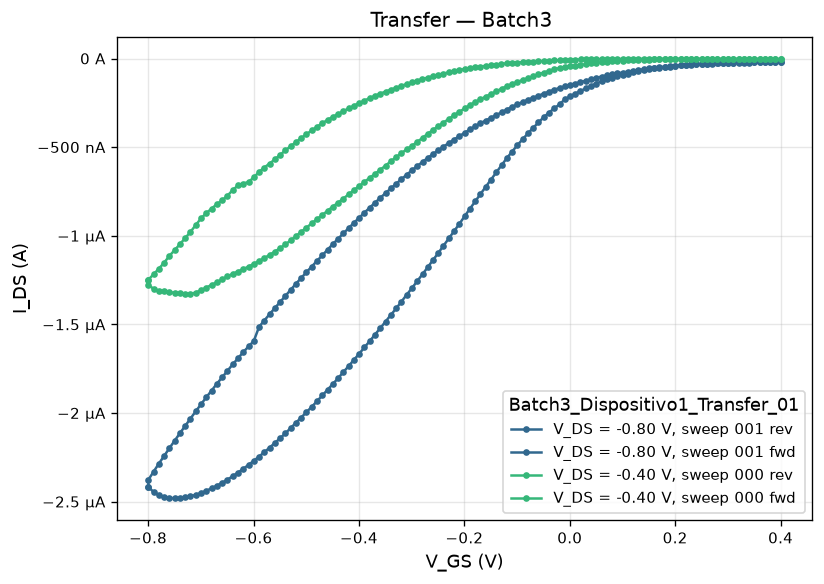

In [15]:

fig, ax = plt.subplots(figsize=(7, 5))
plot_transfer(mt, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'transfer_linear.png'), dpi=150, bbox_inches='tight')

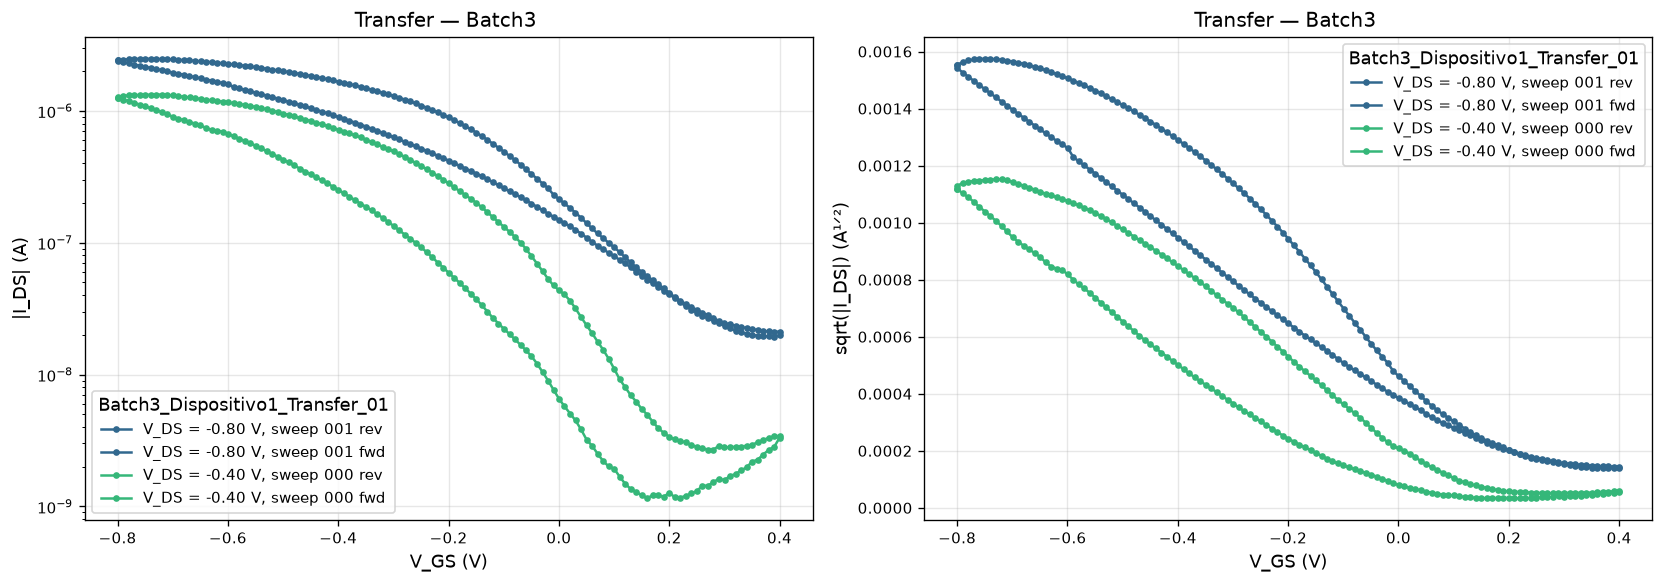

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_transfer(mt, ax=axes[0], log=True)
plot_transfer(mt, ax=axes[1], sqrt=True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'transfer_log_sqrt.png'), dpi=150, bbox_inches='tight')

## Extracción de parámetros

### $V_{th}$ — $\sqrt{I_{DS}}$ (saturación)

In [17]:
r_sqrt = extract_vth_sqrt(mt, vds=-0.8)
print(f"Vth (sqrt) = {r_sqrt['Vth']:.4f} V")
print(f"Slope     = {r_sqrt['slope']:.4e} A¹ᵯ/V")
print(f"R²        = {r_sqrt['R²']:.4f}")

Vth (sqrt) = 0.3720 V
Slope     = -1.3883e-03 A¹ᵯ/V
R²        = 0.9389


### $V_{th}$ — Método lineal

In [18]:
r_lin = extract_vth_linear(mt, vds=-0.4)
print(f"Vth (linear) = {r_lin['Vth']:.4f} V")
print(f"Slope        = {r_lin['slope']:.4e} A/V")
print(f"R²           = {r_lin['R²']:.4f}")

Vth (linear) = 0.1339 V
Slope        = 1.1095e-06 A/V
R²           = 0.7648


### Subthreshold Swing

In [19]:
ss = extract_ss(mt, vds=-0.4)
print(f"SS = {ss['SS']:.4f} V/dec ({ss['SS_mV_dec']:.1f} mV/dec)")

SS = 0.0513 V/dec (51.3 mV/dec)


### Relación $I_{on}/I_{off}$

In [20]:
onoff = extract_on_off_ratio(mt, vds=-0.8)
print(f"I_on  = {onoff['I_on']:.4e} A")
print(f"I_off = {onoff['I_off']:.4e} A")
print(f"On/Off ratio = {onoff['on_off_ratio']:.2e} ({onoff['log_on_off']:.2f} decades)")

I_on  = 2.4807e-06 A
I_off = 1.9371e-08 A
On/Off ratio = 1.28e+02 (2.11 decades)


## Comparativa entre batches

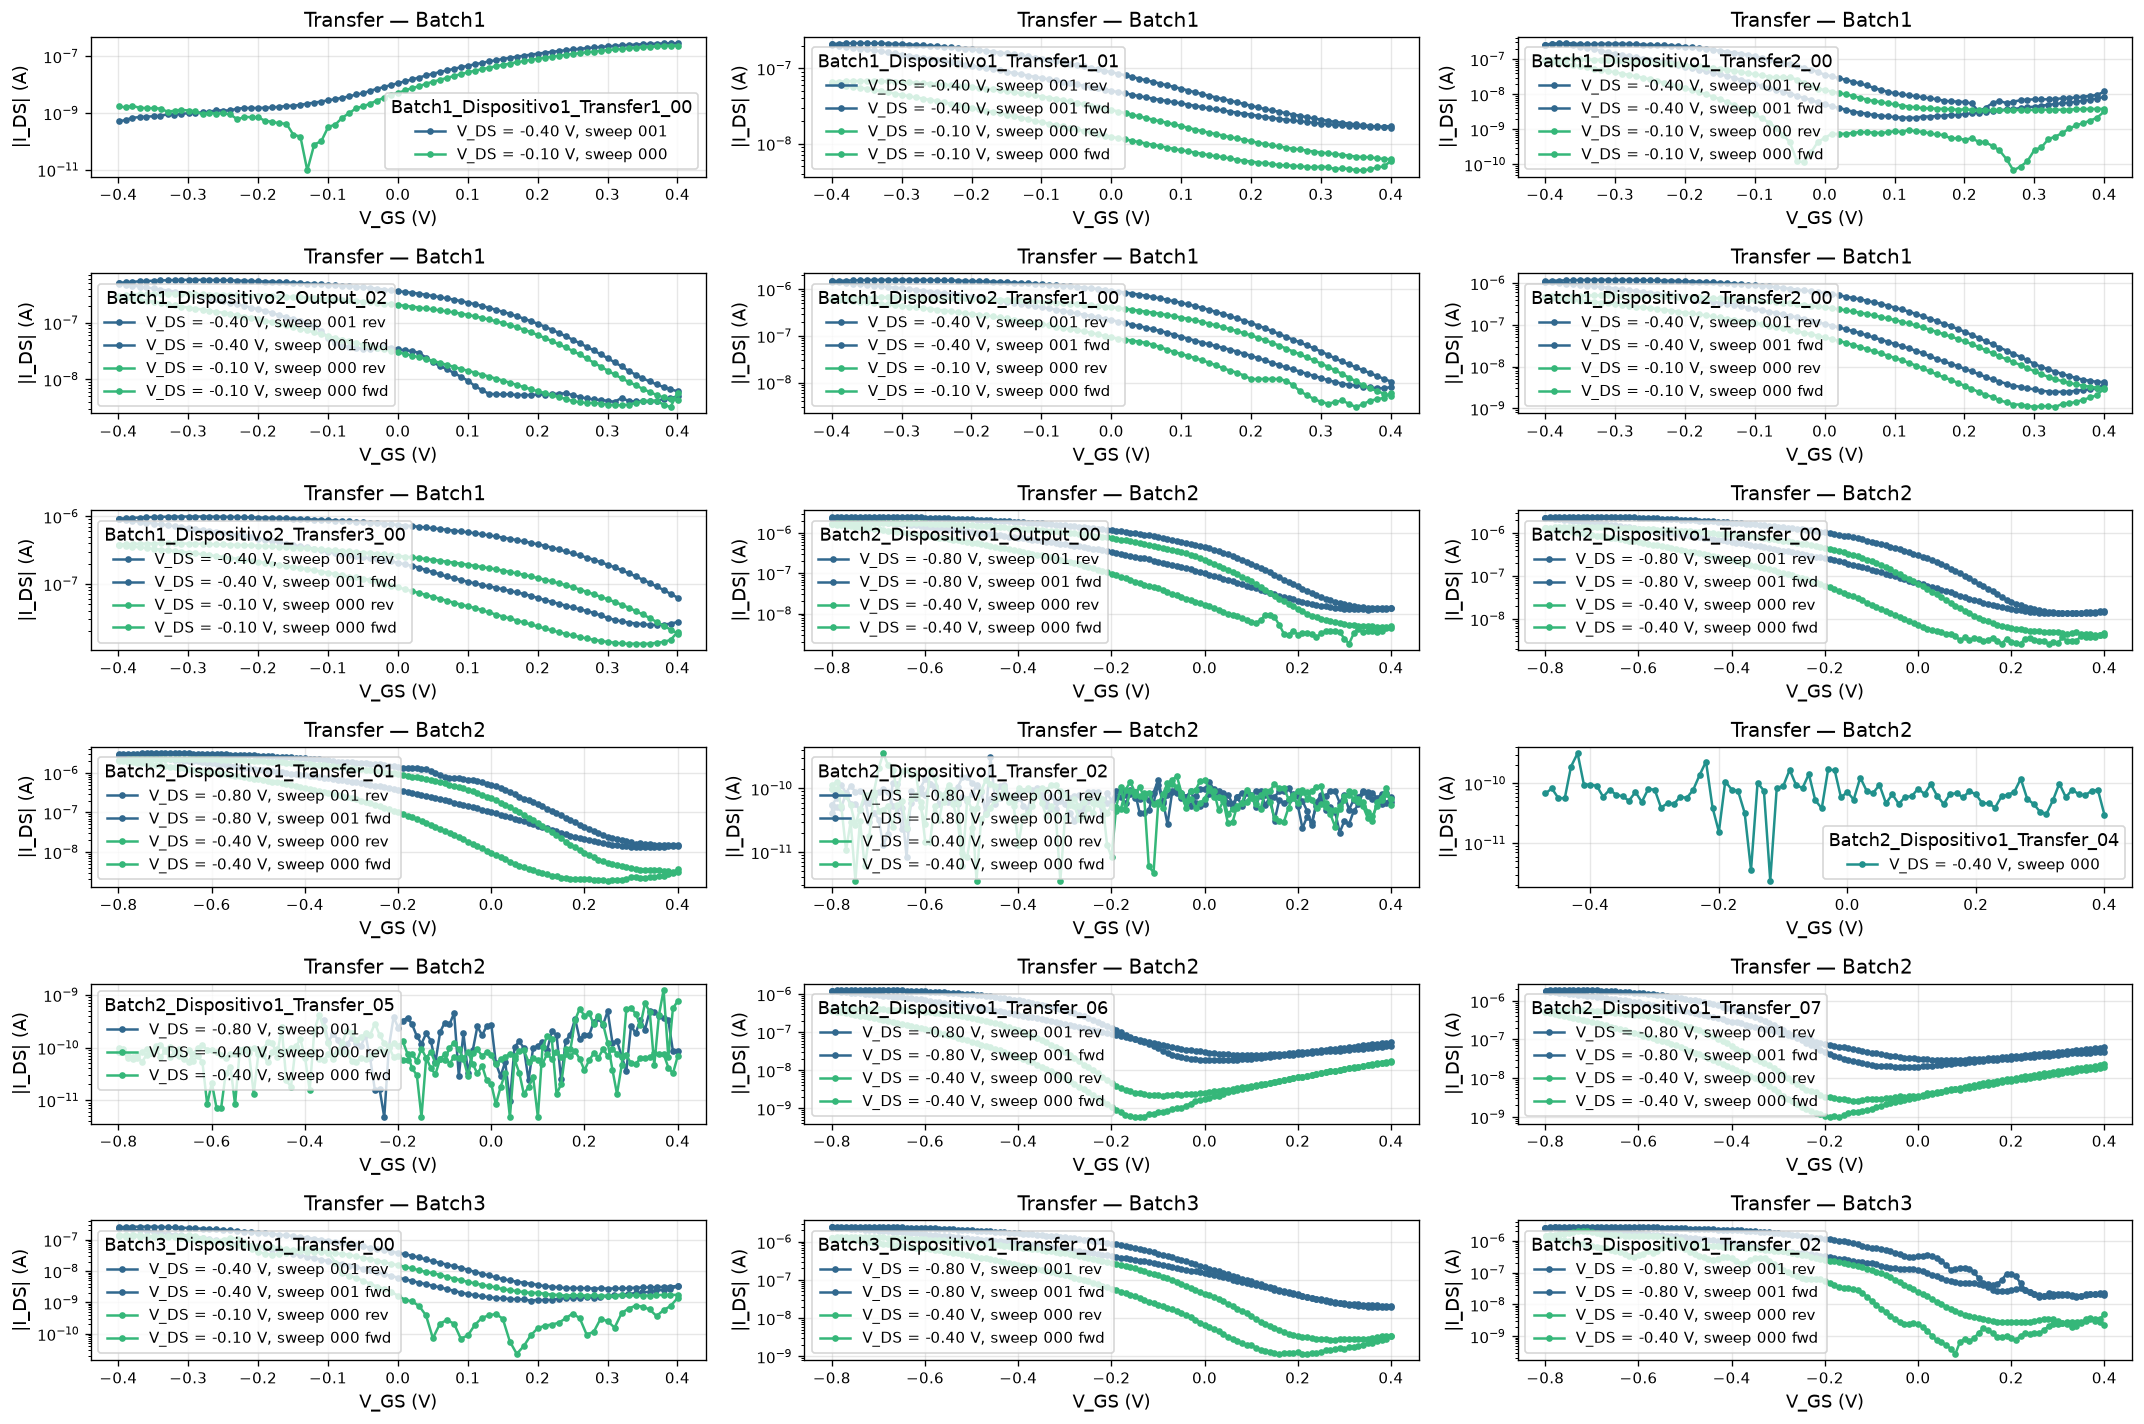

In [21]:
fig, _ = plot_transfer_multi(measurements, log=True, ncols=3, figsize=(18, 12))
plt.savefig(os.path.join(OUT_DIR, 'transfer_all_log.png'), dpi=150, bbox_inches='tight')

## Resumen de parámetros por batch

In [22]:
results = []
for name, m in transfer_ms.items():
    try:
        vds_vals = sorted(m.data['V_DS'].unique())
        vds_high = vds_vals[-1]
        r = extract_vth_sqrt(m, vds=vds_high)
        onoff = extract_on_off_ratio(m, vds=vds_high)
        results.append({
            'name': name,
            'batch': m.batch,
            'device': m.device,
            'V_DS': vds_high,
            'Vth_sqrt': r['Vth'],
            'R²': r['R²'],
            'on_off_log10': onoff['log_on_off'],
        })
    except Exception:
        pass

summary = pd.DataFrame(results)
display(summary.round(4))

,name,batch,device,V_DS,Vth_sqrt,R²,on_off_log10
0,Batch1_Dispositivo1_Transfer1_00,Batch1,,-0.1,-0.2591,0.8211,4.3904
1,Batch1_Dispositivo1_Transfer1_01,Batch1,,-0.1,0.5823,0.8546,1.1877
2,Batch1_Dispositivo1_Transfer2_00,Batch1,,-0.1,0.3415,0.6696,3.1706
3,Batch1_Dispositivo2_Output_02,Batch1,,-0.1,0.4598,0.7113,2.0083
4,Batch1_Dispositivo2_Transfer1_00,Batch1,,-0.1,0.4378,0.8033,2.3517
5,Batch1_Dispositivo2_Transfer2_00,Batch1,,-0.1,0.3793,0.8165,2.6699
6,Batch1_Dispositivo2_Transfer3_00,Batch1,,-0.1,0.5915,0.7803,1.4846
7,Batch2_Dispositivo1_Output_00,Batch2,,-0.4,0.3027,0.8208,3.0065
8,Batch2_Dispositivo1_Transfer_00,Batch2,,-0.4,0.2674,0.8285,2.7249
9,Batch2_Dispositivo1_Transfer_01,Batch2,,-0.4,0.2784,0.8093,3.0906


In [23]:
best = summary[summary['R²'] > 0.9].sort_values('R²', ascending=False)
display(best)

,name,batch,device,V_DS,Vth_sqrt,R²,on_off_log10


---
### Notas
- Las curvas con nombres inconsistentes se detectan por el atributo `measurement_mode`.
- Usar `vgs_range` en `extract_vth_sqrt` para restringir la región de ajuste.